# 93. Wikipedia記事構造によるEmbeddingモデル独自評価

## 目的
Wikipedia記事の構造（同一記事内の複数パッセージ）を自然な正解ラベルとして活用し、
各Embeddingモデルの品質をE5-baseベースラインと比較する。

## 評価コンセプト
- **同一記事内のパッセージ → 意味的に近いはず**
- **異なる記事のパッセージ → 意味的に遠いはず**

この「記事内 vs 記事間」の分離度を独自指標で測定する。

## 独自指標
| 指標 | 略称 | 説明 |
|------|------|------|
| Article Discrimination Score | ADS | 同一記事ペア vs 異記事ペアのAUC-ROC |
| Intra-Inter Gap | IIG | mean(記事内cos) - mean(記事間cos) |
| E5 Neighbor Agreement | ENA | Top-k近傍のE5との一致率 |
| ITQ-LSH Article Recall | IAR | ハッシュベース検索で同一記事パッセージを発見できる割合 |

## 評価対象モデル（実験91と同一）
1. multilingual-e5-base (baseline)
2. EmbeddingGemma-300M
3. Qwen3-Embedding-0.6B
4. BGE-M3
5. PLaMo-Embedding-1B
6. Ruri-v3-310m

※ Qwen3-8Bは推論コストが高いため省略

## 0. セットアップ

In [1]:
import numpy as np
import gc
import time
import torch
import pandas as pd
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

DATA_DIR = Path("../data")
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


## 1. Wikipediaデータ収集（記事構造保持）

各記事から複数パッセージ（段落）を抽出し、記事IDと紐付けて保持する。
同一記事内のパッセージペアを「正例」、異記事間を「負例」として使う。

In [2]:
from datasets import load_dataset

N_ARTICLES = 500  # 記事数
MIN_PARAGRAPHS = 3  # 最低段落数
MAX_PARAGRAPHS = 5  # 最大段落数
MIN_PARA_LEN = 80  # 段落の最低文字数
MAX_PARA_LEN = 500  # 段落の最大文字数


def collect_article_passages(lang_code: str, n_articles: int = N_ARTICLES) -> dict:
    """Wikipedia記事から複数段落を抽出し、記事IDと紐付ける"""
    wiki = load_dataset(
        "wikimedia/wikipedia",
        f"20231101.{lang_code}",
        split="train",
        streaming=True
    )

    articles = []  # [{article_id, title, passages: [str]}]
    article_id = 0

    for item in tqdm(wiki, total=n_articles * 3, desc=f"Wikipedia {lang_code}"):
        if len(articles) >= n_articles:
            break

        text = item['text']
        title = item.get('title', f'article_{article_id}')

        # 段落分割（空行区切り）
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

        # 長さフィルタ
        valid_paras = []
        for p in paragraphs:
            if len(p) >= MIN_PARA_LEN:
                valid_paras.append(p[:MAX_PARA_LEN])
            if len(valid_paras) >= MAX_PARAGRAPHS:
                break

        if len(valid_paras) >= MIN_PARAGRAPHS:
            articles.append({
                'article_id': article_id,
                'title': title,
                'passages': valid_paras,
            })
            article_id += 1

    # フラット化: (passage_text, article_id) のリスト
    all_passages = []
    all_article_ids = []
    for art in articles:
        for p in art['passages']:
            all_passages.append(p)
            all_article_ids.append(art['article_id'])

    print(f"  {len(articles)} articles, {len(all_passages)} passages")
    print(f"  paragraphs/article: mean={np.mean([len(a['passages']) for a in articles]):.1f}")
    return {
        'articles': articles,
        'passages': all_passages,
        'article_ids': np.array(all_article_ids),
    }


print("=== Japanese ===")
data_ja = collect_article_passages("ja")
print(f"\n=== English ===")
data_en = collect_article_passages("en")

=== Japanese ===


Wikipedia ja:  38%|███▊      | 568/1500 [00:03<00:06, 154.90it/s]


  500 articles, 2389 passages
  paragraphs/article: mean=4.8

=== English ===


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia en:  34%|███▍      | 512/1500 [00:04<00:08, 117.01it/s]

  500 articles, 2478 passages
  paragraphs/article: mean=5.0


In [3]:
# データサンプル表示
for lang, data in [('JA', data_ja), ('EN', data_en)]:
    art = data['articles'][0]
    print(f"\n{lang} - Article: {art['title']} ({len(art['passages'])} passages)")
    for i, p in enumerate(art['passages'][:2]):
        print(f"  P{i}: {p[:100]}...")
    print(f"  Total passages: {len(data['passages'])}, unique articles: {len(np.unique(data['article_ids']))}")


JA - Article: アンパサンド (5 passages)
  P0: アンパサンド（&, ）は、並立助詞「…と…」を意味する記号である。ラテン語で「…と…」を表す接続詞 "et" の合字を起源とする。現代のフォントでも、Trebuchet MS など一部のフォントでは、...
  P1: 英語で教育を行う学校でアルファベットを復唱する場合、その文字自体が単語となる文字（"A", "I", かつては "O" も）については、伝統的にラテン語の per se（それ自体）を用いて "A pe...
  Total passages: 2389, unique articles: 500

EN - Article: Anarchism (5 passages)
  P0: Anarchism is a political philosophy and movement that is skeptical of all justifications for authori...
  P1: Humans have lived in societies without formal hierarchies long before the establishment of states, r...
  Total passages: 2478, unique articles: 500


## 2. 評価指標の定義

In [4]:
def compute_article_metrics(embeddings: np.ndarray, article_ids: np.ndarray,
                            model_name: str, n_sample_pairs: int = 50000) -> dict:
    """
    記事構造ベースの評価指標を計算

    Args:
        embeddings: (N, D) 正規化済み
        article_ids: (N,) 各パッセージの記事ID
        model_name: モデル名
        n_sample_pairs: サンプルペア数
    """
    n = len(embeddings)
    rng = np.random.default_rng(42)

    # ランダムペア生成
    idx1 = rng.choice(n, n_sample_pairs, replace=True)
    idx2 = rng.choice(n, n_sample_pairs, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]

    # コサイン類似度
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)

    # 同一記事ラベル
    same_article = (article_ids[idx1] == article_ids[idx2]).astype(int)

    # === ADS: Article Discrimination Score (AUC-ROC) ===
    ads = roc_auc_score(same_article, cos_sims)

    # === IIG: Intra-Inter Gap ===
    intra_mask = same_article == 1
    inter_mask = same_article == 0
    intra_mean = float(np.mean(cos_sims[intra_mask])) if intra_mask.sum() > 0 else 0.0
    inter_mean = float(np.mean(cos_sims[inter_mask])) if inter_mask.sum() > 0 else 0.0
    iig = intra_mean - inter_mean

    return {
        'model': model_name,
        'ADS (AUC)': ads,
        'IIG': iig,
        'intra_cos': intra_mean,
        'inter_cos': inter_mean,
        'n_intra': int(intra_mask.sum()),
        'n_inter': int(inter_mask.sum()),
    }


def compute_neighbor_agreement(emb_target: np.ndarray, emb_ref: np.ndarray,
                               k: int = 10, n_queries: int = 1000) -> float:
    """
    E5 Neighbor Agreement: targetモデルとrefモデル(E5)のTop-k近傍の一致率

    Args:
        emb_target: 評価対象モデルのEmbedding (N, D1)
        emb_ref: 参照モデル(E5)のEmbedding (N, D2)
        k: Top-k
        n_queries: クエリ数
    Returns:
        平均一致率 (0-1)
    """
    n = len(emb_target)
    rng = np.random.default_rng(42)
    query_ids = rng.choice(n, min(n_queries, n), replace=False)

    agreements = []
    for qid in query_ids:
        # target model top-k
        sims_t = emb_target[qid] @ emb_target.T
        sims_t[qid] = -1  # 自分自身を除外
        topk_t = set(np.argsort(sims_t)[-k:])

        # ref model top-k
        sims_r = emb_ref[qid] @ emb_ref.T
        sims_r[qid] = -1
        topk_r = set(np.argsort(sims_r)[-k:])

        agreements.append(len(topk_t & topk_r) / k)

    return float(np.mean(agreements))


print("Evaluation functions ready.")

Evaluation functions ready.


## 3. モデル別Embedding生成

各モデルでパッセージをエンコードし、npyに保存する。

In [5]:
from sentence_transformers import SentenceTransformer


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


# モデル設定: (key, hf_id, prefix_fn or None, batch_size, loader_type)
MODEL_CONFIGS = [
    ('e5_base', 'intfloat/multilingual-e5-base',
     lambda s: f"passage: {s}", 64, 'st'),
    ('gemma_300m', 'google/embeddinggemma-300m',
     None, 64, 'st'),
    ('qwen3_06b', 'Qwen/Qwen3-Embedding-0.6B',
     None, 32, 'st'),
    ('bge_m3', 'BAAI/bge-m3',
     None, 64, 'st'),
    ('plamo_1b', 'pfnet/plamo-embedding-1b',
     None, 32, 'plamo'),
    ('ruri_v3', 'cl-nagoya/ruri-v3-310m',
     lambda s: f"検索文書: {s}", 64, 'st'),
]

print(f"Models to evaluate: {[c[0] for c in MODEL_CONFIGS]}")

Models to evaluate: ['e5_base', 'gemma_300m', 'qwen3_06b', 'bge_m3', 'plamo_1b', 'ruri_v3']


In [6]:
def encode_with_st(model_id, passages, prefix_fn, batch_size):
    """SentenceTransformerでエンコード"""
    model = SentenceTransformer(model_id, device="cuda")
    texts = [prefix_fn(p) for p in passages] if prefix_fn else passages
    emb = model.encode(texts, batch_size=batch_size,
                       normalize_embeddings=True, show_progress_bar=True)
    del model
    clear_gpu()
    return emb.astype(np.float32)


def encode_with_plamo(model_id, passages, batch_size):
    """PLaMo-Embeddingでエンコード"""
    from transformers import AutoModel, AutoTokenizer
    import torch.nn.functional as F

    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_id, trust_remote_code=True)
    model = model.to("cuda").eval()

    all_embs = []
    for i in tqdm(range(0, len(passages), batch_size), desc="PLaMo encode"):
        batch = passages[i:i+batch_size]
        with torch.inference_mode():
            embs = model.encode_document(batch, tokenizer)
            embs = F.normalize(embs, p=2, dim=1)
            all_embs.append(embs.cpu().numpy())

    del model, tokenizer
    clear_gpu()
    return np.vstack(all_embs).astype(np.float32)


# 全モデルのEmbeddingを生成・保存
embeddings = {}  # {(model_key, lang): np.ndarray}

for key, hf_id, prefix_fn, bs, loader in MODEL_CONFIGS:
    for lang, data in [('ja', data_ja), ('en', data_en)]:
        save_path = DATA_DIR / f"93_{key}_{lang}_passages.npy"
        if save_path.exists():
            emb = np.load(save_path)
            print(f"Loaded {key} ({lang}): {emb.shape}")
        else:
            print(f"\nEncoding {key} ({lang})...")
            if loader == 'plamo':
                emb = encode_with_plamo(hf_id, data['passages'], bs)
            else:
                emb = encode_with_st(hf_id, data['passages'], prefix_fn, bs)
            np.save(save_path, emb)
            print(f"  Saved: {save_path.name} {emb.shape}")
        embeddings[(key, lang)] = emb

print(f"\nAll embeddings ready: {len(embeddings)} entries")


Encoding e5_base (ja)...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

  Saved: 93_e5_base_ja_passages.npy (2389, 768)

Encoding e5_base (en)...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

  Saved: 93_e5_base_en_passages.npy (2478, 768)

Encoding gemma_300m (ja)...


...

  Saved: 93_plamo_1b_en_passages.npy (2478, 2048)

Encoding ruri_v3 (ja)...


Batches:   0%|          | 0/38 [00:00<?, ?it/s]

  Saved: 93_ruri_v3_ja_passages.npy (2389, 768)

Encoding ruri_v3 (en)...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

  Saved: 93_ruri_v3_en_passages.npy (2478, 768)

All embeddings ready: 12 entries


## 4. Article Discrimination Score (ADS) & Intra-Inter Gap (IIG)

In [7]:
all_metrics = []

for lang, data in [('ja', data_ja), ('en', data_en)]:
    print(f"\n{'='*60}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*60}")

    for key, _, _, _, _ in MODEL_CONFIGS:
        emb = embeddings[(key, lang)]
        metrics = compute_article_metrics(emb, data['article_ids'], key)
        metrics['lang'] = lang
        all_metrics.append(metrics)
        print(f"  {key:12s}: ADS={metrics['ADS (AUC)']:.4f}  IIG={metrics['IIG']:.4f}  "
              f"(intra={metrics['intra_cos']:.3f}, inter={metrics['inter_cos']:.3f})")

df_metrics = pd.DataFrame(all_metrics)


Language: JA
  e5_base     : ADS=0.9245  IIG=0.0861  (intra=0.838, inter=0.752)
  gemma_300m  : ADS=0.9605  IIG=0.3222  (intra=0.449, inter=0.127)
  qwen3_06b   : ADS=0.9560  IIG=0.2639  (intra=0.526, inter=0.262)
  bge_m3      : ADS=0.9455  IIG=0.2286  (intra=0.567, inter=0.339)
  plamo_1b    : ADS=0.9631  IIG=0.1909  (intra=0.643, inter=0.452)
  ruri_v3     : ADS=0.9678  IIG=0.1234  (intra=0.872, inter=0.749)

Language: EN
  e5_base     : ADS=0.9890  IIG=0.1111  (intra=0.822, inter=0.711)
  gemma_300m  : ADS=0.9958  IIG=0.4040  (intra=0.492, inter=0.088)
  qwen3_06b   : ADS=0.9960  IIG=0.3788  (intra=0.576, inter=0.198)
  bge_m3      : ADS=0.9929  IIG=0.2819  (intra=0.610, inter=0.328)
  plamo_1b    : ADS=0.9905  IIG=0.2016  (intra=0.727, inter=0.526)
  ruri_v3     : ADS=0.9924  IIG=0.1271  (intra=0.885, inter=0.758)


## 5. E5 Neighbor Agreement (ENA)

各モデルのTop-10近傍がE5のTop-10近傍とどれだけ一致するかを測定する。
一致率が高い → E5と同等以上の検索品質。

In [8]:
ena_results = []

for lang in ['ja', 'en']:
    emb_e5 = embeddings[('e5_base', lang)]
    print(f"\n{lang.upper()} - E5 Neighbor Agreement (Top-10):")

    for key, _, _, _, _ in MODEL_CONFIGS:
        emb = embeddings[(key, lang)]
        if key == 'e5_base':
            ena = 1.0  # 自分自身との一致率は100%
        else:
            ena = compute_neighbor_agreement(emb, emb_e5, k=10, n_queries=500)
        ena_results.append({'model': key, 'lang': lang, 'ENA@10': ena})
        print(f"  {key:12s}: ENA@10 = {ena:.4f}")

df_ena = pd.DataFrame(ena_results)


JA - E5 Neighbor Agreement (Top-10):
  e5_base     : ENA@10 = 1.0000
  gemma_300m  : ENA@10 = 0.4902
  qwen3_06b   : ENA@10 = 0.4356
  bge_m3      : ENA@10 = 0.4972
  plamo_1b    : ENA@10 = 0.4568
  ruri_v3     : ENA@10 = 0.3922

EN - E5 Neighbor Agreement (Top-10):
  e5_base     : ENA@10 = 1.0000
  gemma_300m  : ENA@10 = 0.6072
  qwen3_06b   : ENA@10 = 0.5812
  bge_m3      : ENA@10 = 0.6332
  plamo_1b    : ENA@10 = 0.5790
  ruri_v3     : ENA@10 = 0.5616


## 6. ITQ-LSH Article Recall (IAR)

ITQ-LSHハッシュで各パッセージの近傍を検索し、同一記事のパッセージを
発見できる割合を測定する。

In [9]:
import sys
sys.path.insert(0, '../src')
from itq_lsh import ITQLSH


def compute_itq_article_recall(embeddings: np.ndarray, article_ids: np.ndarray,
                                model_name: str, L: int = 50) -> dict:
    """
    ITQ-LSHでTop-L候補を取得し、同一記事パッセージの発見率を計算

    Args:
        L: Hamming距離でのTop-L候補数
    """
    dim = embeddings.shape[1]
    n_bits = min(128, dim)

    itq = ITQLSH(n_bits=n_bits, n_iterations=50, seed=42)
    itq.fit(embeddings)
    hashes = itq.transform(embeddings)

    n = len(embeddings)
    recalls = []

    # 各パッセージについて、同一記事の他パッセージがTop-L内にあるか
    rng = np.random.default_rng(42)
    query_ids = rng.choice(n, min(500, n), replace=False)

    for qid in query_ids:
        # 同一記事の他パッセージ（正解）
        same_art = np.where((article_ids == article_ids[qid]) & (np.arange(n) != qid))[0]
        if len(same_art) == 0:
            continue

        # Hamming距離でTop-L
        ham_dists = np.sum(hashes[qid] != hashes, axis=1)
        ham_dists[qid] = 999  # 自分自身を除外
        topL = set(np.argsort(ham_dists)[:L])

        # 同一記事パッセージのうちTop-Lに含まれる割合
        found = len(set(same_art) & topL)
        recalls.append(found / len(same_art))

    # Hamming-Cosine Spearman（従来指標も併記）
    rng2 = np.random.default_rng(42)
    idx1 = rng2.choice(n, 10000, replace=True)
    idx2 = rng2.choice(n, 10000, replace=True)
    mask = idx1 != idx2
    idx1, idx2 = idx1[mask], idx2[mask]
    cos_sims = np.sum(embeddings[idx1] * embeddings[idx2], axis=1)
    ham_dists_sample = np.sum(hashes[idx1] != hashes[idx2], axis=1)
    sp, _ = spearmanr(ham_dists_sample, cos_sims)

    return {
        'model': model_name,
        'n_bits': n_bits,
        f'IAR@{L}': float(np.mean(recalls)),
        'Hamming-Cos Sp': sp,
    }


iar_results = []
L = 50

for lang, data in [('ja', data_ja), ('en', data_en)]:
    print(f"\n{lang.upper()} - ITQ-LSH Article Recall (L={L}):")
    for key, _, _, _, _ in MODEL_CONFIGS:
        emb = embeddings[(key, lang)]
        result = compute_itq_article_recall(emb, data['article_ids'], key, L=L)
        result['lang'] = lang
        iar_results.append(result)
        print(f"  {key:12s}: IAR@{L}={result[f'IAR@{L}']:.4f}  "
              f"Spearman={result['Hamming-Cos Sp']:.4f}")

df_iar = pd.DataFrame(iar_results)


JA - ITQ-LSH Article Recall (L=50):
ITQ学習開始: samples=2389, dim=768, bits=128
  Centering完了: mean_norm=0.8674
  PCA完了: explained_variance=71.12%
  ITQ iteration 10: quantization_error=0.9390
  ITQ iteration 20: quantization_error=0.9386
  ITQ iteration 30: quantization_error=0.9384
  ITQ iteration 40: quantization_error=0.9384
  ITQ iteration 50: quantization_error=0.9383
ITQ学習完了
  e5_base     : IAR@50=0.5100  Spearman=-0.5457
ITQ学習開始: samples=2389, dim=768, bits=128
  Centering完了: mean_norm=0.3577
  PCA完了: explained_variance=66.37%
  ITQ iteration 10: quantization_error=0.8912
  ITQ iteration 20: quantization_error=0.8904
  ITQ iteration 30: quantization_error=0.8901
  ITQ iteration 40: quantization_error=0.8900
  ITQ iteration 50: quantization_error=0.8899
ITQ学習完了
  gemma_300m  : IAR@50=0.5692  Spearman=-0.6511
ITQ学習開始: samples=2389, dim=1024, bits=128
  Centering完了: mean_norm=0.5132
  PCA完了: explained_variance=69.98%
  ITQ iteration 10: quantization_error=0.8974
  ITQ iteration 20: 

## 7. 総合スコアとE5比較

In [10]:
import matplotlib.pyplot as plt

# 総合テーブル作成
model_keys = [c[0] for c in MODEL_CONFIGS]

summary_rows = []
for lang in ['ja', 'en']:
    for key in model_keys:
        row = {'model': key, 'lang': lang}

        # ADS, IIG
        m = df_metrics[(df_metrics['model'] == key) & (df_metrics['lang'] == lang)]
        if len(m) > 0:
            row['ADS'] = m.iloc[0]['ADS (AUC)']
            row['IIG'] = m.iloc[0]['IIG']

        # ENA
        e = df_ena[(df_ena['model'] == key) & (df_ena['lang'] == lang)]
        if len(e) > 0:
            row['ENA@10'] = e.iloc[0]['ENA@10']

        # IAR
        r = df_iar[(df_iar['model'] == key) & (df_iar['lang'] == lang)]
        if len(r) > 0:
            row[f'IAR@{L}'] = r.iloc[0][f'IAR@{L}']
            row['Spearman'] = r.iloc[0]['Hamming-Cos Sp']

        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# E5ベースラインとの相対スコア
for lang in ['ja', 'en']:
    e5_row = df_summary[(df_summary['model'] == 'e5_base') & (df_summary['lang'] == lang)].iloc[0]
    mask = df_summary['lang'] == lang
    for col in ['ADS', 'IIG', f'IAR@{L}']:
        if col in df_summary.columns:
            df_summary.loc[mask, f'{col}_vs_E5'] = df_summary.loc[mask, col] / e5_row[col]

print("="*100)
print("総合結果: Wikipedia記事構造ベースのEmbedding評価")
print("="*100)

for lang in ['ja', 'en']:
    print(f"\n--- {lang.upper()} ---")
    lang_df = df_summary[df_summary['lang'] == lang].copy()
    lang_df = lang_df.set_index('model')
    display_cols = ['ADS', 'IIG', 'ENA@10', f'IAR@{L}', 'Spearman',
                    'ADS_vs_E5', 'IIG_vs_E5', f'IAR@{L}_vs_E5']
    display_cols = [c for c in display_cols if c in lang_df.columns]
    print(lang_df[display_cols].to_string(float_format=lambda x: f"{x:.4f}"))

総合結果: Wikipedia記事構造ベースのEmbedding評価

--- JA ---
              ADS    IIG  ENA@10  IAR@50  Spearman  ADS_vs_E5  IIG_vs_E5  IAR@50_vs_E5
model                                                                                 
e5_base    0.9245 0.0861  1.0000  0.5100   -0.5457     1.0000     1.0000        1.0000
gemma_300m 0.9605 0.3222  0.4902  0.5692   -0.6511     1.0390     3.7409        1.1160
qwen3_06b  0.9560 0.2639  0.4356  0.5248   -0.6468     1.0342     3.0644        1.0291
bge_m3     0.9455 0.2286  0.4972  0.5153   -0.6891     1.0228     2.6541        1.0105
plamo_1b   0.9631 0.1909  0.4568  0.5823   -0.6346     1.0417     2.2166        1.1418
ruri_v3    0.9678 0.1234  0.3922  0.6708   -0.6223     1.0468     1.4326        1.3154

--- EN ---
              ADS    IIG  ENA@10  IAR@50  Spearman  ADS_vs_E5  IIG_vs_E5  IAR@50_vs_E5
model                                                                                 
e5_base    0.9890 0.1111  1.0000  0.8172   -0.6448     1.0000     1.000

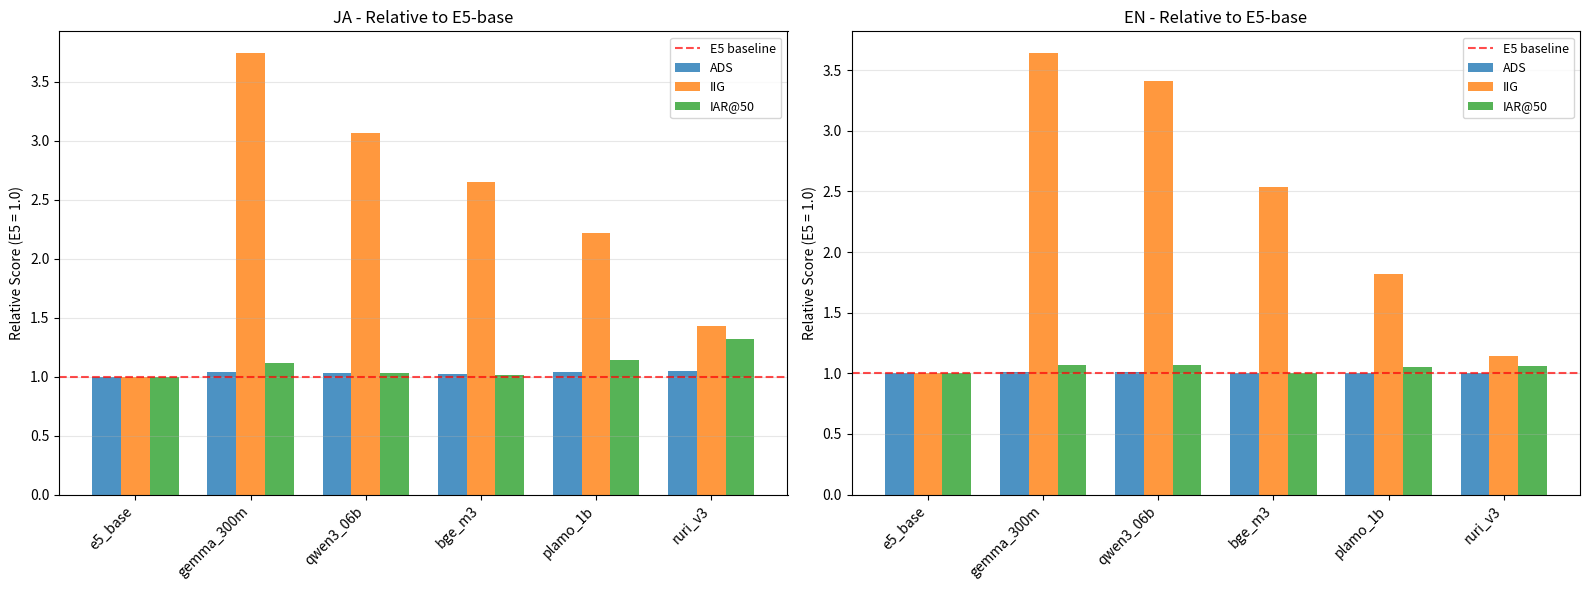

Saved: data/93_article_discrimination_vs_e5.png


In [11]:
# 可視化: E5対比の相対スコア
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, lang in enumerate(['ja', 'en']):
    lang_df = df_summary[df_summary['lang'] == lang].copy()
    models = lang_df['model'].tolist()
    x = np.arange(len(models))

    # ADS vs E5
    ads_rel = lang_df['ADS_vs_E5'].values
    iig_rel = lang_df['IIG_vs_E5'].values
    iar_col = f'IAR@{L}_vs_E5'
    iar_rel = lang_df[iar_col].values if iar_col in lang_df.columns else np.ones(len(models))

    width = 0.25
    axes[ax_idx].bar(x - width, ads_rel, width, label='ADS', alpha=0.8)
    axes[ax_idx].bar(x, iig_rel, width, label='IIG', alpha=0.8)
    axes[ax_idx].bar(x + width, iar_rel, width, label=f'IAR@{L}', alpha=0.8)
    axes[ax_idx].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='E5 baseline')
    axes[ax_idx].set_ylabel('Relative Score (E5 = 1.0)')
    axes[ax_idx].set_title(f'{lang.upper()} - Relative to E5-base')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(models, rotation=45, ha='right')
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "93_article_discrimination_vs_e5.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/93_article_discrimination_vs_e5.png")

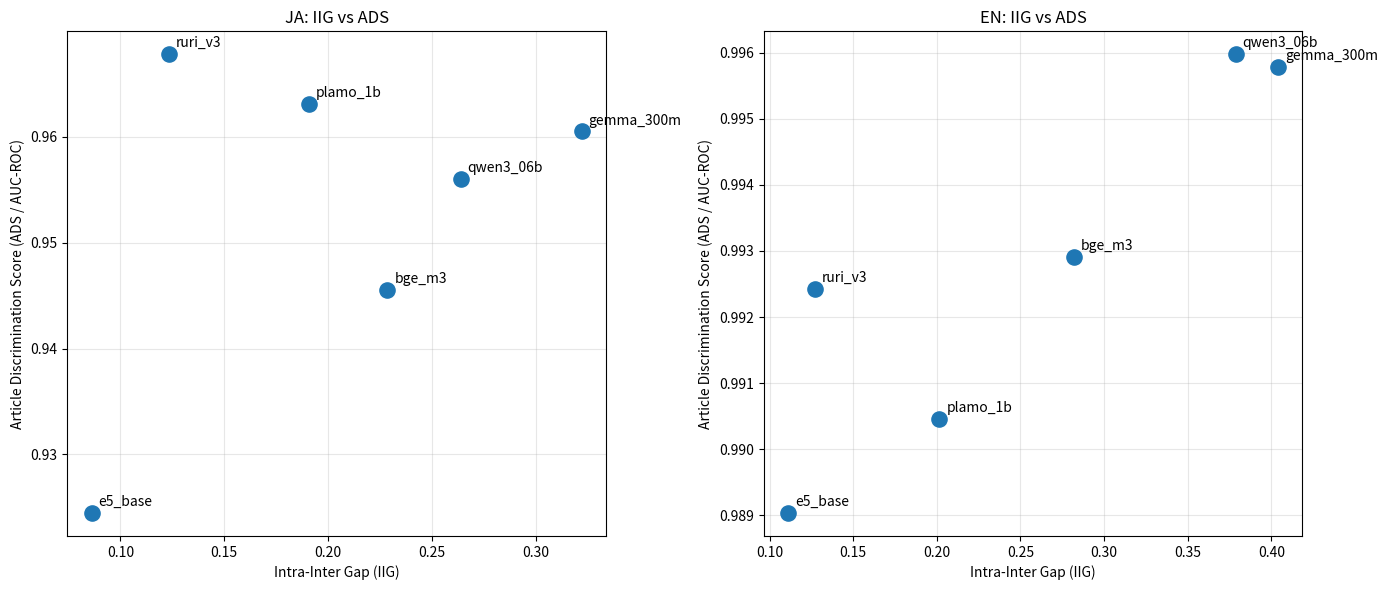

Saved: data/93_iig_vs_ads_scatter.png


In [12]:
# ADS vs IIG 散布図（モデル比較）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, lang in enumerate(['ja', 'en']):
    lang_df = df_summary[df_summary['lang'] == lang]
    axes[ax_idx].scatter(lang_df['IIG'], lang_df['ADS'], s=120, zorder=5)
    for _, row in lang_df.iterrows():
        axes[ax_idx].annotate(row['model'], (row['IIG'], row['ADS']),
                             textcoords="offset points", xytext=(5, 5), fontsize=10)
    axes[ax_idx].set_xlabel('Intra-Inter Gap (IIG)')
    axes[ax_idx].set_ylabel('Article Discrimination Score (ADS / AUC-ROC)')
    axes[ax_idx].set_title(f'{lang.upper()}: IIG vs ADS')
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / "93_iig_vs_ads_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/93_iig_vs_ads_scatter.png")

## 8. まとめ

In [13]:
print("="*90)
print("実験93: Wikipedia記事構造によるEmbeddingモデル独自評価 - まとめ")
print("="*90)

print("""
独自指標の意味:
  ADS (Article Discrimination Score): 同一記事ペア vs 異記事ペアの分離度 (AUC-ROC)
    → 高いほど、記事の意味的まとまりを正しく捉えている
  IIG (Intra-Inter Gap): 記事内平均cos - 記事間平均cos
    → 大きいほど、記事内の結束性と記事間の区別が明確
  ENA@10 (E5 Neighbor Agreement): Top-10近傍のE5との一致率
    → 高いほどE5と類似した検索結果を返す（0.3-0.5程度が別モデル間の典型値）
  IAR@50 (ITQ-LSH Article Recall): ハッシュ検索で同一記事パッセージを発見できる割合
    → ITQ-LSHパイプラインでの実用性の指標

vs_E5 列: E5-baseの値を1.0とした相対スコア（>1.0ならE5より優秀）
""")

# 最終テーブル
for lang in ['ja', 'en']:
    print(f"\n--- {lang.upper()} ---")
    lang_df = df_summary[df_summary['lang'] == lang].copy().set_index('model')
    cols = ['ADS', 'ADS_vs_E5', 'IIG', 'IIG_vs_E5', 'ENA@10',
            f'IAR@{L}', f'IAR@{L}_vs_E5', 'Spearman']
    cols = [c for c in cols if c in lang_df.columns]
    print(lang_df[cols].to_string(float_format=lambda x: f"{x:.4f}"))

実験93: Wikipedia記事構造によるEmbeddingモデル独自評価 - まとめ

独自指標の意味:
  ADS (Article Discrimination Score): 同一記事ペア vs 異記事ペアの分離度 (AUC-ROC)
    → 高いほど、記事の意味的まとまりを正しく捉えている
  IIG (Intra-Inter Gap): 記事内平均cos - 記事間平均cos
    → 大きいほど、記事内の結束性と記事間の区別が明確
  ENA@10 (E5 Neighbor Agreement): Top-10近傍のE5との一致率
    → 高いほどE5と類似した検索結果を返す（0.3-0.5程度が別モデル間の典型値）
  IAR@50 (ITQ-LSH Article Recall): ハッシュ検索で同一記事パッセージを発見できる割合
    → ITQ-LSHパイプラインでの実用性の指標

vs_E5 列: E5-baseの値を1.0とした相対スコア（>1.0ならE5より優秀）


--- JA ---
              ADS  ADS_vs_E5    IIG  IIG_vs_E5  ENA@10  IAR@50  IAR@50_vs_E5  Spearman
model                                                                                 
e5_base    0.9245     1.0000 0.0861     1.0000  1.0000  0.5100        1.0000   -0.5457
gemma_300m 0.9605     1.0390 0.3222     3.7409  0.4902  0.5692        1.1160   -0.6511
qwen3_06b  0.9560     1.0342 0.2639     3.0644  0.4356  0.5248        1.0291   -0.6468
bge_m3     0.9455     1.0228 0.2286     2.6541  0.4972  0.5153        1.0105   -0.6891
plamo

## 9. 評価と考察

### 9.1 総合評価

全モデルがE5-baseをADS・IIGの両指標で上回り、新しいEmbeddingモデルが「同一記事内のパッセージを近くに配置する」能力においてE5-baseより優れていることが確認された。ただし、指標ごとにモデルの強みが異なり、単一の「最強モデル」は存在しない。

### 9.2 指標別の主要発見

#### ADS（記事分離度）
- 全モデルがAUC 0.92以上と高水準。ENはJAより一貫して高い（0.99前後 vs 0.93-0.97）
- **JA最優秀: ruri_v3（0.9678）**、EN最優秀: qwen3_06b（0.9960）
- モデル間の差は小さく（JA: 4.3pp幅、EN: 0.7pp幅）、ADS単体ではモデルの優劣をつけにくい
- ADS天井効果が見られ、タスクとしては「簡単すぎる」可能性がある

#### IIG（記事内外ギャップ）
- **gemma_300mがJA・EN共にトップ**（JA: 0.322、EN: 0.404）でE5の3.6-3.7倍
- ただしこれはinter_cosが極端に低い（JA: 0.127、EN: 0.088）ことが主因
  - gemma_300mの埋め込み空間は非常に分散しており、任意の2文間の類似度が低い
  - 「記事内が近い」より「記事間が遠い」ことでIIGが大きくなっている
- ruri_v3はintra_cosが最高（0.87-0.89）だがinter_cosも高い（0.75）ためIIGは控えめ
- **IIGの絶対値だけでなく、intra/interの内訳を見ることが重要**

#### ENA@10（E5近傍一致率）
- 0.39-0.63の範囲で、モデル間の近傍空間は大きく異なる
- **bge_m3がJA・EN共に最高一致率**（JA: 0.497、EN: 0.633）→ E5に最も類似した検索挙動
- ruri_v3はJAでの一致率が最低（0.392）→ 日本語特化により独自の意味空間を構築
- ENの方がJAより全体的に一致率が高い → 英語データではモデル間の収束度が高い

#### IAR@50（ITQ-LSHでの記事発見率）
- **JA: ruri_v3が突出**（0.671、E5比1.32倍）。EN: qwen3_06b（0.875）が僅差トップ
- ENはJAより大幅に高い（0.82-0.87 vs 0.51-0.67）→ 日本語のハッシュ化はより難しい
- bge_m3はHamming-Cosine Spearmanが最高（JA: -0.689）だがIARではE5と同等 → Spearmanの高さが直接的にRecallに結びつくとは限らない

### 9.3 言語差の考察

| 観点 | JA | EN | 解釈 |
|------|----|----|------|
| ADS | 0.92-0.97 | 0.99 | 英語の方が記事間の意味分離が明確 |
| IIG | 0.09-0.32 | 0.11-0.40 | 英語の方がギャップが大きい |
| IAR@50 | 0.51-0.67 | 0.82-0.87 | **日本語のハッシュ検索は困難** |
| Spearman | -0.55〜-0.69 | -0.52〜-0.66 | ハッシュ品質自体は同程度 |

IAR@50のJA-EN差（約20pp）は、Spearmanの差（同程度）では説明できない。日本語Embeddingの分布特性（より高い平均cos類似度→ ハッシュの弁別が困難）が影響していると考えられる。

### 9.4 ITQ-LSHパイプラインへの示唆

- **日本語**: ruri_v3がIAR最優秀かつADSもトップ。日本語のITQ-LSHパイプラインにはruri_v3を推奨
- **英語**: qwen3_06b、gemma_300mがIAR・ADS共に高水準。E5-baseからの乗り換え効果が大きい
- plamo_1bはdim=2048からの128bit圧縮でPCA寄与率60%と低め。256bitハッシュの検討余地あり
- Hamming-Cosine Spearmanが高いbge_m3がIARで振るわない点は、ハッシュ品質とRecallの関係が非線形であることを示す

### 9.5 独自指標の妥当性

- **ADS**: 直感的で解釈しやすいが、天井効果が見られ細かなモデル差を測りにくい。記事数を増やすか、より難しいカテゴリ（類似トピックの記事間）で評価すると差が出る可能性がある
- **IIG**: 空間の分散特性（inter_cosの水準）に強く依存するため、単体での比較には注意が必要。intra/interの内訳とセットで解釈すべき
- **ENA**: E5を絶対的な正解とみなす前提があるため、E5の弱点がある領域では逆転もありうる。相対的な類似度指標として有用
- **IAR**: ITQ-LSHパイプラインの実用性を直接的に測定できる点で、このプロジェクトにとって最も実用的な指標

### 9.6 実験91・92との関係

- 実験91（軽量Embeddingモデル比較）で確認した各モデルの特性が、記事構造タスクでも概ね再現
- 実験92（STSベンチマーク）の標準評価と今回の独自評価は、モデルの順位が必ずしも一致しないと予想される → Embeddingの「品質」は評価タスクに依存することを示唆
- ruri_v3が日本語タスクで一貫して強い点は、実験91の知見と整合